In [ ]:
# Análisis de reingresos en pacientes diabéticos

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# 1. Cargar datos
df = pd.read_csv("../data/raw/diabetic_data.csv")
mapping = pd.read_csv("../data/raw/IDS_mapping.csv")

print("Shape inicial:", df.shape)
df.head()

Shape inicial: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# 2. Análisis exploratorio de datos (EDA)
# Verificar valores faltantes
df.isna().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
encounter_id                    0
patient_nbr                     0
number_inpatient                0
number_emergency                0
diag_1                          0
diag_2                          0
number_diagnoses                0
diag_3                          0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
# 3. Reemplazar símbolos que representan valores faltantes
df = df.replace(['?', 'Unknown/Invalid'], np.nan)

# 4. Verificar valores faltantes reales después del reemplazo
df.isna().sum().sort_values(ascending=False)


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
gender                          3
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
patient_nbr                     0
discharge_disposition_id        0
admission_type_id               0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
# 5. Eliminar columnas demasiado vacías (más del 80% nulas)
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
df = df.drop(columns=cols_to_drop)

# 6. Imputar columnas con pocos nulos (rellenar con "Unknown")
df[['race', 'diag_1', 'diag_2', 'diag_3', 'gender']] = df[['race', 'diag_1', 'diag_2', 'diag_3', 'gender']].fillna('Unknown')

# 7. Verificar valores faltantes nuevamente
df.isna().sum().sort_values(ascending=False)


encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide

In [ ]:
# 8. Convertir el rango de edad en un número (edad aproximada)
def interval_to_midpoint(x):
    lo, hi = x.strip('[]()').split('-')
    return (int(lo) + int(hi)) / 2

df['age_num'] = df['age'].apply(interval_to_midpoint)
df[['age', 'age_num']].head()


,age,age_num
0,[0-10),5.0
1,[10-20),15.0
2,[20-30),25.0
3,[30-40),35.0
4,[40-50),45.0


In [ ]:
# 9. Crear nuevas variables que sean útiles para el análisis

# elderly (edad >= 65)
df['elderly'] = (df['age_num'] >= 65).astype(int)

# polypharmacy (más de 10 medicamentos)
df['polypharmacy'] = (df['num_medications'] >= 10).astype(int)

# readmitted_30d (reingreso en menos de 30 días)
df['readmitted_30d'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Verificar las nuevas columnas
df[['age_num', 'elderly', 'num_medications', 'polypharmacy', 'readmitted', 'readmitted_30d']].head()


,age_num,elderly,num_medications,polypharmacy,readmitted,readmitted_30d
0,5.0,0,1,0,NO,0
1,15.0,0,18,1,>30,0
2,25.0,0,13,1,NO,0
3,35.0,0,16,1,NO,0
4,45.0,0,8,0,NO,0


In [ ]:
# 10. Creacion de Diccionarios (según documentación del dataset)

admission_type_map = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'Not Available',
    6: 'NULL',
    7: 'Trauma Center',
    8: 'Not Mapped'
}

discharge_disposition_map = {
    1: 'Discharged to home',
    2: 'Discharged to another short term hospital',
    3: 'Discharged to SNF',
    4: 'Discharged to ICF',
    5: 'Discharged to another type inpatient care institution',
    6: 'Discharged to home with home health service',
    7: 'Left AMA',
    8: 'Discharged to home under care of home IV provider',
    9: 'Admitted as inpatient to this hospital',
    10: 'Neonate discharged to another hospital',
    11: 'Expired',
    12: 'Still patient',
    13: 'Hospice - home',
    14: 'Hospice - medical facility',
    15: 'Discharged/transferred within institution',
    16: 'Discharged/transferred to another institution for outpatient services',
    17: 'Discharged/transferred to this institution for outpatient services',
    18: 'NULL',
    19: 'Expired at home',
    20: 'Expired in a medical facility',
    21: 'Expired - Medicaid only',
    22: 'Expired at home - Medicaid only - hospice',
    23: 'Not Available',
    24: 'Not Mapped',
    25: 'Unknown/Invalid'
}

admission_source_map = {
    1: 'Physician Referral',
    2: 'Clinic Referral',
    3: 'HMO Referral',
    4: 'Emergency Room',
    5: 'Transfer from a hospital',
    6: 'Transfer from a Skilled Nursing Facility',
    7: 'Transfer from another health care facility',
    8: 'Emergency Room (other)',
    9: 'Not Available',
    10: 'Transfer from Critical Access Hospital',
    11: 'Normal Delivery',
    12: 'Premature Birth',
    13: 'Sick Baby',
    14: 'Extramural Birth',
    15: 'Not Mapped',
    17: 'NULL',
    20: 'Court/Law Enforcement',
    21: 'Unknown/Invalid'
}



In [ ]:
# 11. Mapear en el dataframe principal

# admission type
df['admission_type_desc'] = df['admission_type_id'].map(admission_type_map)

# discharge disposition
df['discharge_disposition_desc'] = df['discharge_disposition_id'].map(discharge_disposition_map)

# admission source
df['admission_source_desc'] = df['admission_source_id'].map(admission_source_map)

# Verificar resultado
df[['admission_type_id', 'admission_type_desc',
    'discharge_disposition_id', 'discharge_disposition_desc',
    'admission_source_id', 'admission_source_desc']].head()


,admission_type_id,admission_type_desc,discharge_disposition_id,discharge_disposition_desc,admission_source_id,admission_source_desc
0,6,NULL,25,Unknown/Invalid,1,Physician Referral
1,1,Emergency,1,Discharged to home,7,Transfer from another health care facility
2,1,Emergency,1,Discharged to home,7,Transfer from another health care facility
3,1,Emergency,1,Discharged to home,7,Transfer from another health care facility
4,1,Emergency,1,Discharged to home,7,Transfer from another health care facility


In [ ]:
#11.b. # Crear grupo clínico correcto de alta hospitalaria

df['discharge_group'] = np.select(
    [
        df['discharge_disposition_id'].isin([1, 6, 8]),          # Home
        df['discharge_disposition_id'].isin([3, 4, 5]),          # LT Care
        df['discharge_disposition_id'].isin([16, 17]),           # Outpatient (CLAVE)
        df['discharge_disposition_id'].isin([2, 10, 15]),        # Transfer
        df['discharge_disposition_id'].isin([11, 19, 20, 21, 22])# Expired
    ],
    [
        'Home',
        'LT Care',
        'Outpatient',
        'Transfer',
        'Expired'
    ],
    default='Unknown'
)


In [ ]:
# 12. Agrupar diagnóstico principal en categorías clínicas

def group_diag(x):
    try:
        code = int(float(x))
    except:
        return "Other"
    
    if 390 <= code <= 459 or code == 785:
        return "Circulatory"
    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"
    elif 520 <= code <= 579 or code == 787:
        return "Digestive"
    elif 250 <= code <= 251:
        return "Diabetes"
    elif 800 <= code <= 999:
        return "Injury"
    elif 140 <= code <= 239:
        return "Neoplasms"
    else:
        return "Other"

df['diag_group'] = df['diag_1'].apply(group_diag)

df[['diag_1', 'diag_group']].head()


,diag_1,diag_group
0,250.83,Diabetes
1,276,Other
2,648,Other
3,8,Other
4,197,Neoplasms


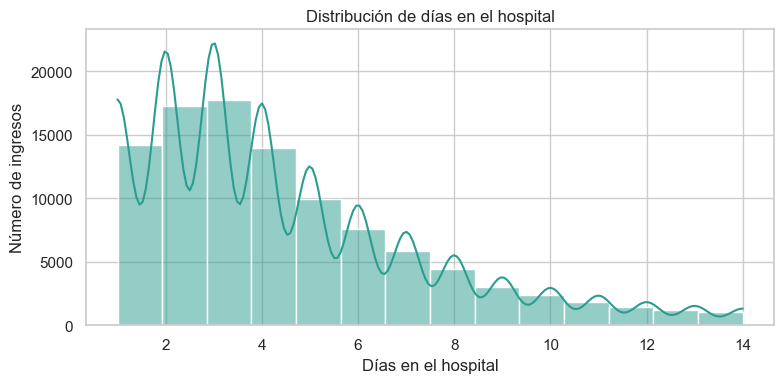

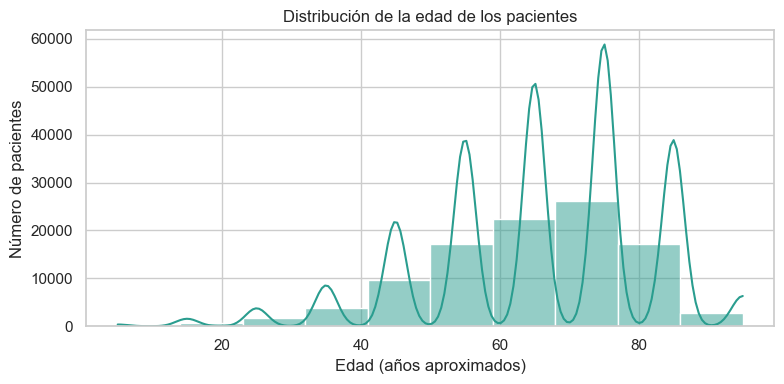

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.0)

main_color = "#2a9d8f"      # teal
secondary_color = "#264653" # azul oscuro
accent_color = "#e76f51"    # coral

# 13. Histograma de días en el hospital

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='time_in_hospital', bins=14, kde=True, color=main_color)
plt.title('Distribución de días en el hospital')
plt.xlabel('Días en el hospital')
plt.ylabel('Número de ingresos')
plt.tight_layout()
plt.show()

# 14. Histograma de edad

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age_num', bins=10, kde=True, color=main_color)
plt.title('Distribución de la edad de los pacientes')
plt.xlabel('Edad (años aproximados)')
plt.ylabel('Número de pacientes')
plt.tight_layout()
plt.show()


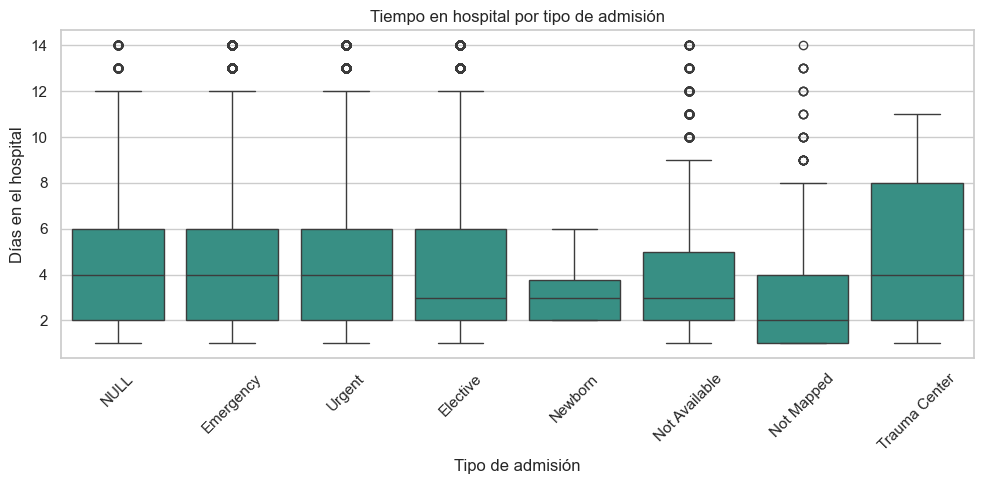

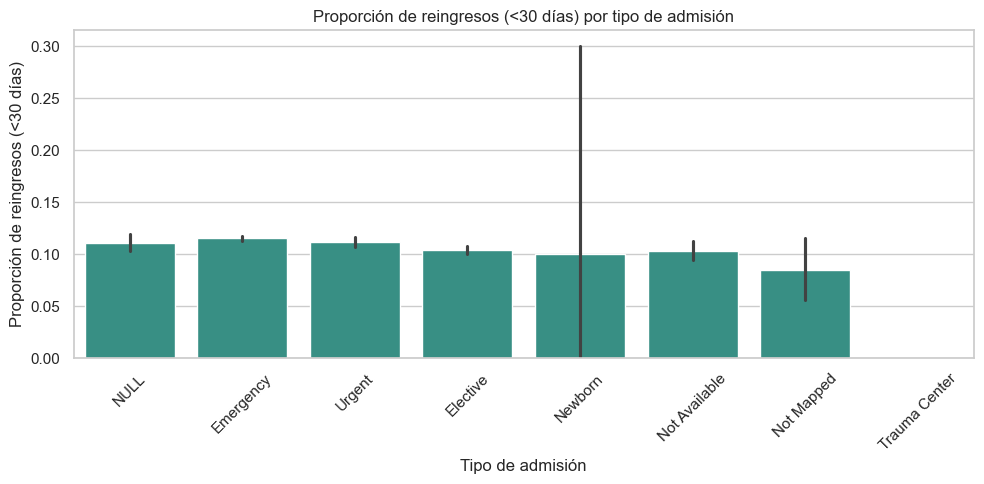

In [ ]:
# 15. Boxplot: días en hospital por tipo de admisión

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='admission_type_desc', y='time_in_hospital', color=main_color)
plt.title('Tiempo en hospital por tipo de admisión')
plt.xlabel('Tipo de admisión')
plt.ylabel('Días en el hospital')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 16. Proporción de reingresos <30d por tipo de admisión

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='admission_type_desc',
    y='readmitted_30d',
    estimator=np.mean,
    color=main_color
)
plt.title('Proporción de reingresos (<30 días) por tipo de admisión')
plt.xlabel('Tipo de admisión')
plt.ylabel('Proporción de reingresos (<30 días)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


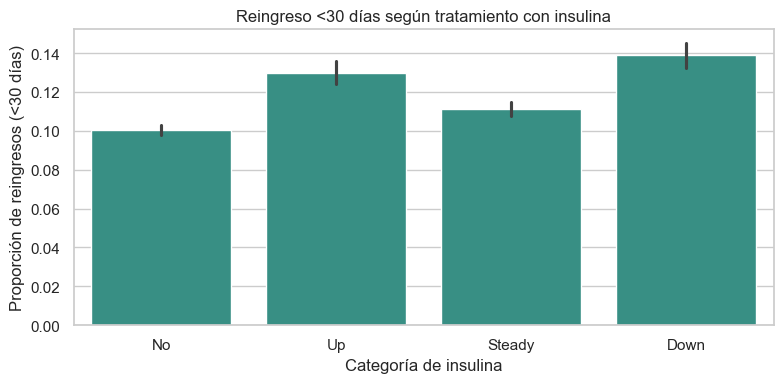

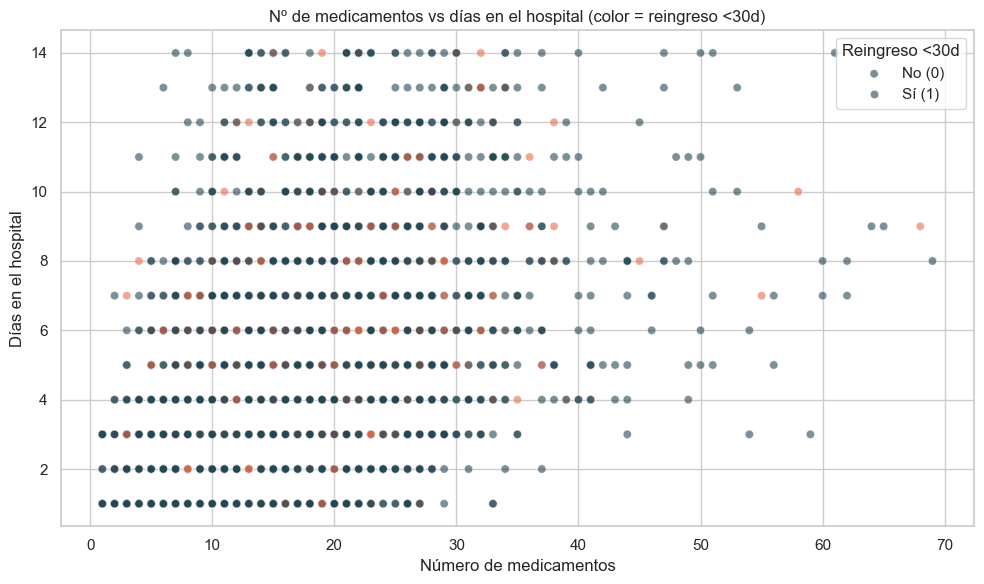

In [ ]:
# 17. Reingreso <30d por categoría de insulina

plt.figure(figsize=(8, 4))
sns.barplot(
    data=df,
    x='insulin',
    y='readmitted_30d',
    estimator=np.mean,
    color=main_color
)
plt.title('Reingreso <30 días según tratamiento con insulina')
plt.xlabel('Categoría de insulina')
plt.ylabel('Proporción de reingresos (<30 días)')
plt.tight_layout()
plt.show()

# 18. Dispersión: num_medications vs time_in_hospital

palette_reingreso = {0: secondary_color, 1: accent_color}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='num_medications',
    y='time_in_hospital',
    hue='readmitted_30d',
    palette=palette_reingreso,
    alpha=0.6
)
plt.title('Nº de medicamentos vs días en el hospital (color = reingreso <30d)')
plt.xlabel('Número de medicamentos')
plt.ylabel('Días en el hospital')
plt.legend(title='Reingreso <30d', labels=['No (0)', 'Sí (1)'])
plt.tight_layout()
plt.show()


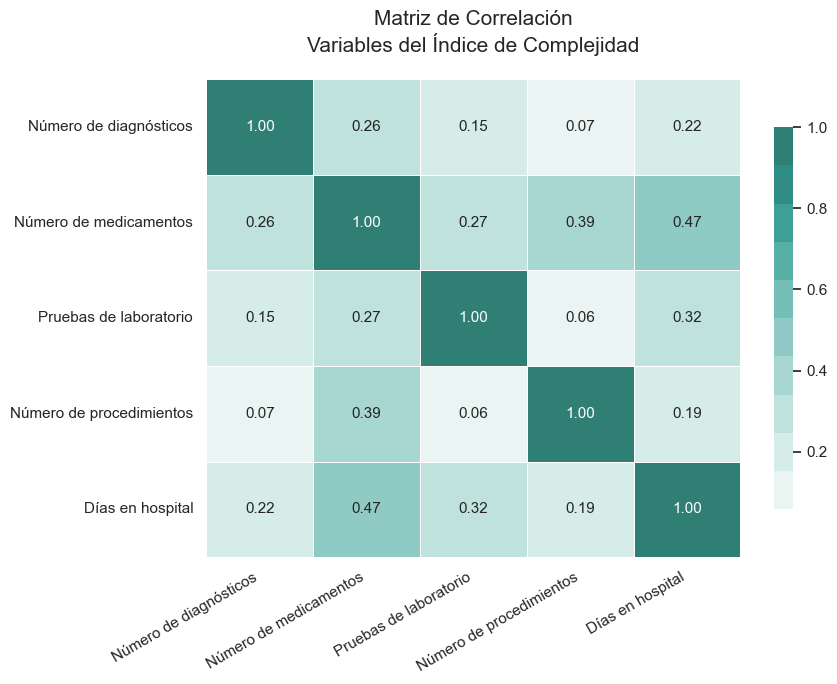

In [ ]:
# 19. Heatmap de correlaciones de variables clínicas clave


# Variables del índice
variables = [
    'number_diagnoses',
    'num_medications',
    'num_lab_procedures',
    'num_procedures',
    'time_in_hospital'
]

# Calcular correlación
corr = df[variables].corr()

# Renombrar columnas para visualización
corr.columns = [
    'Número de diagnósticos',
    'Número de medicamentos',
    'Pruebas de laboratorio',
    'Número de procedimientos',
    'Días en hospital'
]
corr.index = corr.columns

plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(["#EAF5F3", "#D5ECE8", "#BFE2DD", "#A8D7D1", "#8FCBC4", "#73BEB6", "#57AFA6", "#3F9E95", "#2F8D85", "#2F7F75"], as_cmap=True),
    linewidths=0.5,
    annot_kws={"size":11},
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Matriz de Correlación\nVariables del Índice de Complejidad",
    fontsize=15,
    pad=20
)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()




In [ ]:
# 21. Estadísticas descriptivas generales

df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [ ]:
# 22. Estadísticas de variables clínicas clave

df[['time_in_hospital', 'num_medications', 'age_num',
    'number_inpatient', 'number_outpatient',
    'number_emergency']].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
age_num,101766.0,65.967022,15.940838,5.0,55.0,65.0,75.0,95.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0


In [ ]:
# 23. Tasa global de reingreso <30d

reingreso_global = df['readmitted_30d'].mean()
print(f"Tasa global de reingreso <30d: {reingreso_global:.3f} ({reingreso_global*100:.1f}%)")

# 24. Proporción de polifarmacia

poly_prop = df['polypharmacy'].mean()
print(f"Proporción de pacientes con polifarmacia: {poly_prop:.3f} ({poly_prop*100:.1f}%)")


Tasa global de reingreso <30d: 0.112 (11.2%)
Proporción de pacientes con polifarmacia: 0.798 (79.8%)


In [ ]:
# 25. Guardar dataset limpio para futuros modelos

df.to_csv("../data/processed/diabetic_data_clean.csv", index=False)
print("Archivo guardado en data/processed correctamente.")


Archivo 'diabetic_data_clean.csv' guardado correctamente.


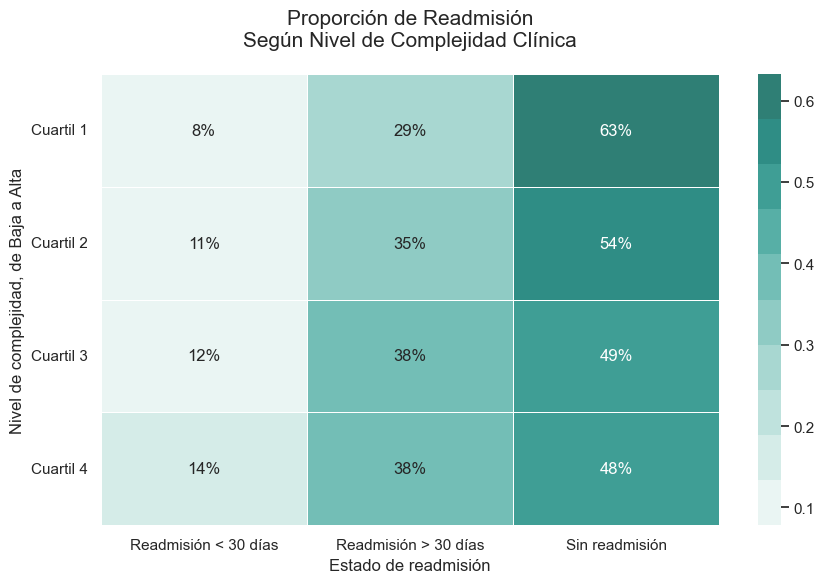

In [ ]:
# 26. Heatmap: Complejidad Clínica vs Readmisión


# Crear índice de complejidad clínica (consistente con variables ya usadas)
df['indice_complejidad'] = (
    df['number_diagnoses'] +
    df['num_medications'] +
    df['number_inpatient'] +
    df['number_emergency'] +
    df['time_in_hospital']
)

# Crear cuartiles
df['cuartil_complejidad'] = pd.qcut(
    df['indice_complejidad'],
    4,
    labels=['Cuartil 1', 'Cuartil 2', 'Cuartil 3', 'Cuartil 4']
)

# Tabla cruzada normalizada por fila
tabla = pd.crosstab(
    df['cuartil_complejidad'],
    df['readmitted'],
    normalize='index'
)

# Renombrar columnas para visualización
tabla = tabla.rename(columns={
    '<30': 'Readmisión < 30 días',
    '>30': 'Readmisión > 30 días',
    'NO': 'Sin readmisión'
})

# Asegurar orden correcto de columnas
tabla = tabla[
    ['Readmisión < 30 días',
     'Readmisión > 30 días',
     'Sin readmisión']
]

# Crear heatmap
plt.figure(figsize=(9,6))

sns.heatmap(
    tabla,
    annot=True,
    cmap=sns.color_palette(["#EAF5F3", "#D5ECE8", "#BFE2DD", "#A8D7D1", "#8FCBC4", "#73BEB6", "#57AFA6", "#3F9E95", "#2F8D85", "#2F7F75"], as_cmap=True),
    fmt=".0%",
    linewidths=0.5
)

plt.title(
    "Proporción de Readmisión\nSegún Nivel de Complejidad Clínica",
    fontsize=15,
    pad=20
)

plt.xlabel("Estado de readmisión")
plt.ylabel("Nivel de complejidad, de Baja a Alta")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()